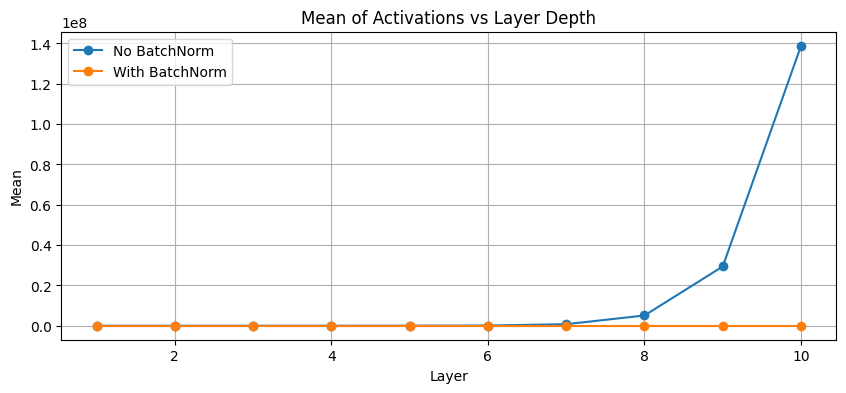

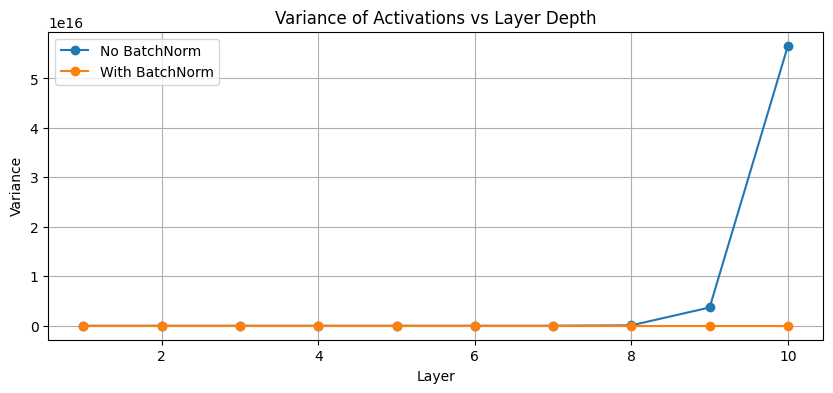

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------
# Activation
# --------------------------------
def relu(x):
    return np.maximum(0, x)

# --------------------------------
# Forward Pass
# --------------------------------
def forward_pass(X, weights, use_batchnorm=False):
    means = []
    variances = []
    
    out = X
    for W in weights:
        z = out @ W
        
        if use_batchnorm:
            mu = np.mean(z, axis=0)
            sigma = np.std(z, axis=0) + 1e-5
            z = (z - mu) / sigma
        
        out = relu(z)
        
        means.append(np.mean(out))
        variances.append(np.var(out))
    
    return means, variances

# --------------------------------
# Settings (small dataset)
# --------------------------------
np.random.seed(42)
num_layers = 10
input_dim = 50
hidden_dim = 50
num_samples = 200  # small number of points

# Bad init to exaggerate covariate shift
weights = [np.random.randn(input_dim if i == 0 else hidden_dim, hidden_dim) * 1.5
           for i in range(num_layers)]

X = np.random.randn(num_samples, input_dim)

# --------------------------------
# Compute statistics
# --------------------------------
means_no_bn, vars_no_bn = forward_pass(X, weights, use_batchnorm=False)
means_bn, vars_bn = forward_pass(X, weights, use_batchnorm=True)

layers = np.arange(1, num_layers + 1)

# --------------------------------
# Plot: Mean Across Depth
# --------------------------------
plt.figure(figsize=(10, 4))
plt.plot(layers, means_no_bn, marker='o', label='No BatchNorm')
plt.plot(layers, means_bn, marker='o', label='With BatchNorm')
plt.title("Mean of Activations vs Layer Depth")
plt.xlabel("Layer")
plt.ylabel("Mean")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------
# Plot: Variance Across Depth
# --------------------------------
plt.figure(figsize=(10, 4))
plt.plot(layers, vars_no_bn, marker='o', label='No BatchNorm')
plt.plot(layers, vars_bn, marker='o', label='With BatchNorm')
plt.title("Variance of Activations vs Layer Depth")
plt.xlabel("Layer")
plt.ylabel("Variance")
plt.grid(True)
plt.legend()
plt.show()
